<a href="https://colab.research.google.com/github/Abel-Kurian/Ai-internship/blob/main/Day6_Deep_Learning_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

#load dataset
data = keras.datasets.mnist
(x_train,y_train),(x_test,y_test) = data.load_data()


#normalize data (scaling pixel values to range 0-1
x_train = x_train / 255.0
x_test = x_test /255.0

#build a simple neural network
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

#compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#train the model
model.fit(x_train,y_train,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9261 - loss: 0.2584
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9657 - loss: 0.1153
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9760 - loss: 0.0788
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9812 - loss: 0.0599
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9853 - loss: 0.0464


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9775 - loss: 0.0730
test accuracy: 0.9775000214576721
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Enter the test num:9


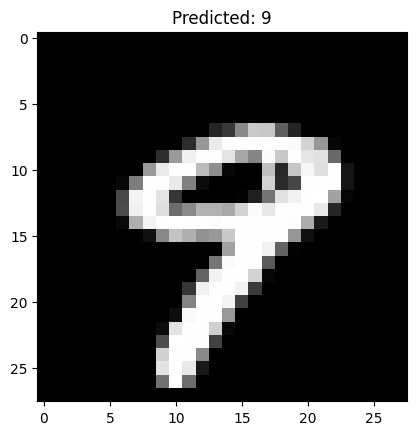

In [21]:
#evaluate on test data
test_loss,test_acc = model.evaluate(x_test,y_test)
print("test accuracy:",test_acc)

#display the sample predictions
predictions = model.predict(x_test)

test_num = int(input("Enter the test num:"))
plt.imshow(x_test[test_num],cmap="gray")
plt.title(f"Predicted: {np.argmax(predictions[test_num])}")
plt.show()


Subplot model for number images


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 32ms/step - accuracy: 0.9618 - loss: 0.1271 - val_accuracy: 0.9867 - val_loss: 0.0419
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9870 - loss: 0.0422 - val_accuracy: 0.9873 - val_loss: 0.0357
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9911 - loss: 0.0292 - val_accuracy: 0.9892 - val_loss: 0.0352
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9932 - loss: 0.0199 - val_accuracy: 0.9898 - val_loss: 0.0330
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9951 - loss: 0.0155 - val_accuracy: 0.9923 - val_loss: 0.0252
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9923 - loss: 0.0252
test accuracy: 0.9922999739646912
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


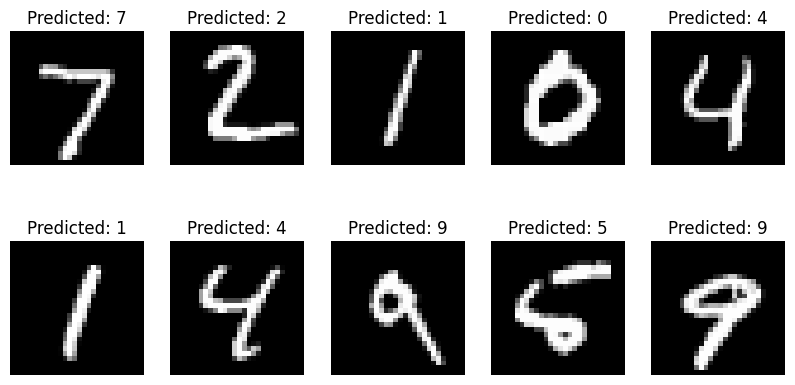

In [28]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

#load dataset
data = keras.datasets.mnist
(x_train,y_train),(x_test,y_test) = data.load_data()


#normalize data (scaling pixel values to range 0-1
x_train = x_train / 255.0
x_test = x_test /255.0

#resape data to include channel dim (28,28,1)
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

#build a simple neural network
model = keras.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

#compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#train the model
model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

#evaluate model
test_loss,test_acc = model.evaluate(x_test,y_test)
print("test accuracy:",test_acc)

#predict on test images
predicitons = model.predict(x_test)

#plot some predictions
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)

    plt.imshow(x_test[i].reshape(28,28),cmap="gray")
    plt.title(f"Predicted: {np.argmax(predictions[i])}")
    plt.axis("off")
plt.show()